# Assignment 2 — Part 3: Personal Optimisation Problem

**Topic:** Optimal Weekly Step Planning to Maximise Calorie Burn  
**Data:** Personal daily activity log (steps, distance, calories) — 31 days


## Data Loading and Exploratory Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize, curve_fit
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

#  Load data
df = pd.read_excel('distance.xlsx')
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset overview:")
print(f"  Days recorded : {len(df)}")
print(f"  Date range    : 1/3/2026 to 31/3/2026")
print(f"  Columns       : {list(df.columns)}")
print()
print(df[['Steps', 'Distance', 'Calories']].describe().round(1).to_string())

Dataset overview:
  Days recorded : 31
  Date range    : 1/3/2026 to 31/3/2026
  Columns       : ['Date', 'Steps', 'Start_time', 'End_time', 'Distance', 'Weekdays', 'Calories']

         Steps  Distance  Calories
count     31.0      31.0      31.0
mean    7258.8       5.2     275.0
std     6213.5       4.7     245.8
min      971.0       0.6      18.3
25%     2101.0       1.6      78.3
50%     4518.0       3.5     188.0
75%    10983.0       8.0     458.5
max    20866.0      16.3     857.0


**Practically visualising the whole dataset**

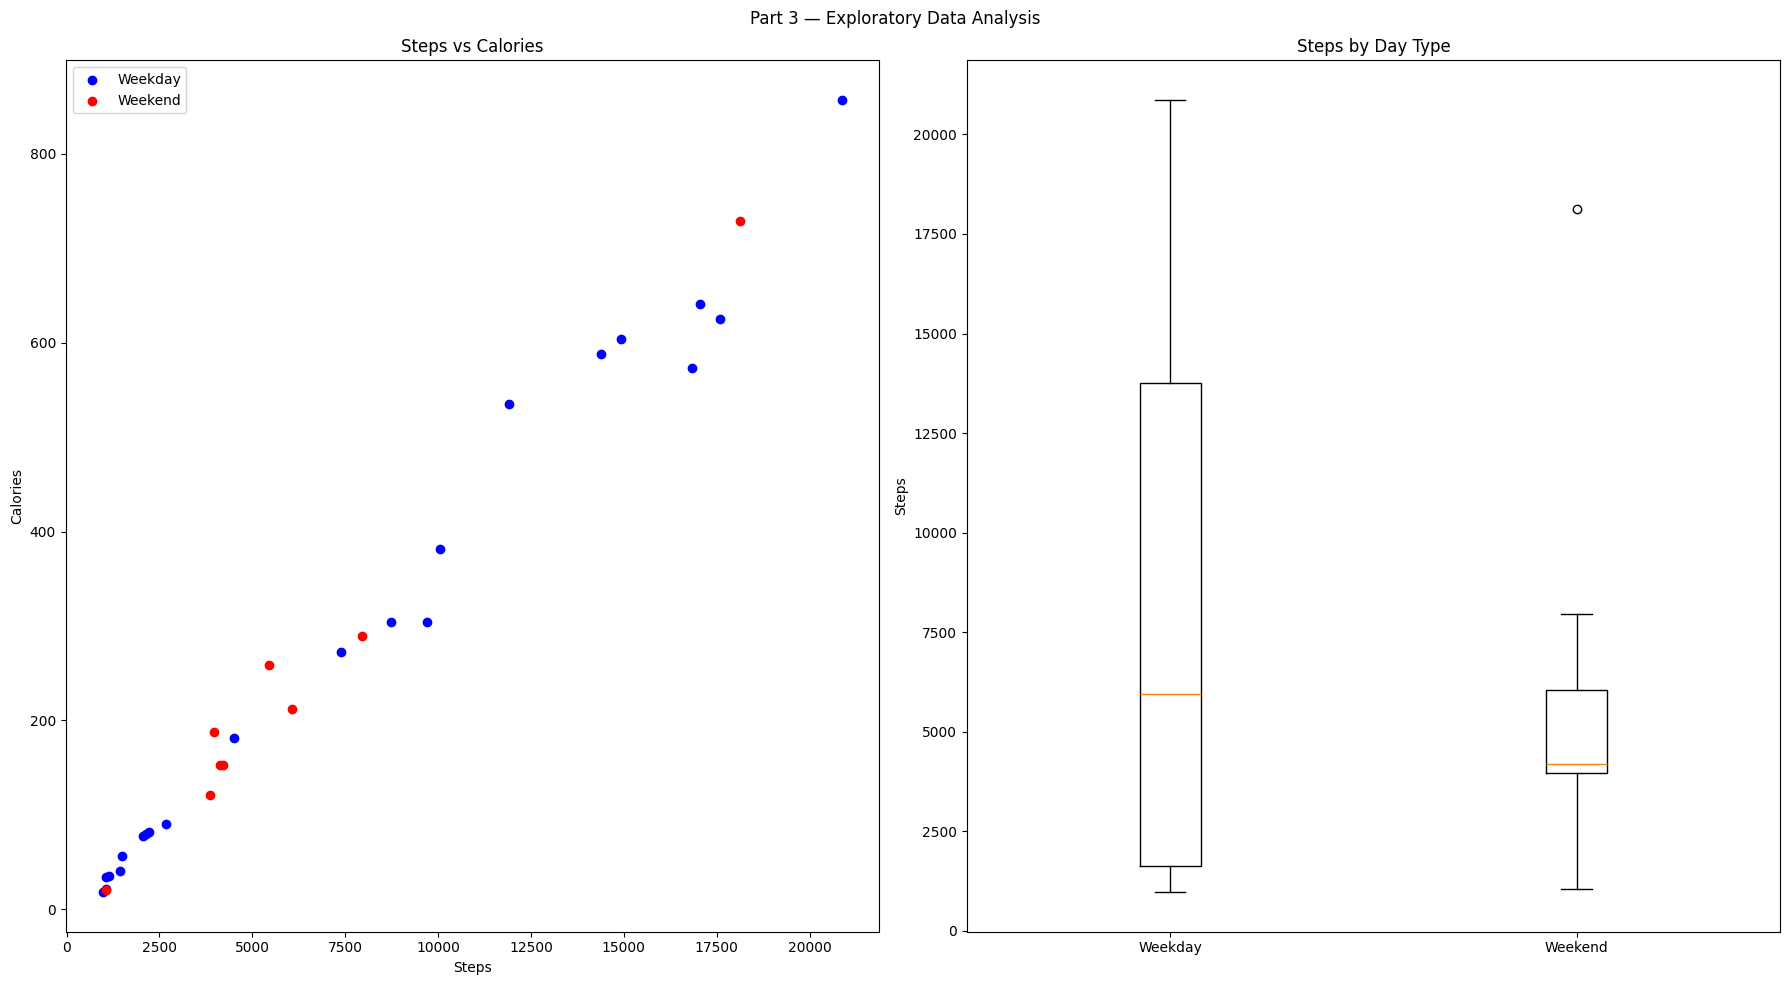

In [3]:
plt.figure(figsize=(18, 10))

# 1. Steps vs Calories
plt.subplot(1, 2, 1)

# Plotting 'weekday' data
plt.scatter(df[df['Weekdays']=='weekday']['Steps'],
            df[df['Weekdays']=='weekday']['Calories'],
            color='blue', label='Weekday')

# Plotting 'weekend' data
plt.scatter(df[df['Weekdays']=='weekend']['Steps'],
            df[df['Weekdays']=='weekend']['Calories'],
            color='red', label='Weekend')

plt.title('Steps vs Calories')
plt.xlabel('Steps')
plt.ylabel('Calories')
plt.legend()


# 2. Boxplot
plt.subplot(1, 2, 2)

groups = [
    df[df['Weekdays']=='weekday']['Steps'],
    df[df['Weekdays']=='weekend']['Steps']
]

plt.boxplot(groups, labels=['Weekday', 'Weekend'])

plt.title('Steps by Day Type')
plt.ylabel('Steps')


# Final layout
plt.suptitle('Part 3 — Exploratory Data Analysis')
plt.tight_layout()
plt.savefig('part3_eda.png', dpi=150)
plt.show()

##  Model
 A **power-law model** is used:

$$\text{Calories}(s) = a \cdot s^{\,b}$$




Power-law model fit:  Calories = a · Steps^b
  a = 0.027151  (±0.010231)
  b = 1.036359  (±0.039324)
  R² = 0.9822

Interpretation: b = 1.036
  Increasing returns (more steps = much more calories)


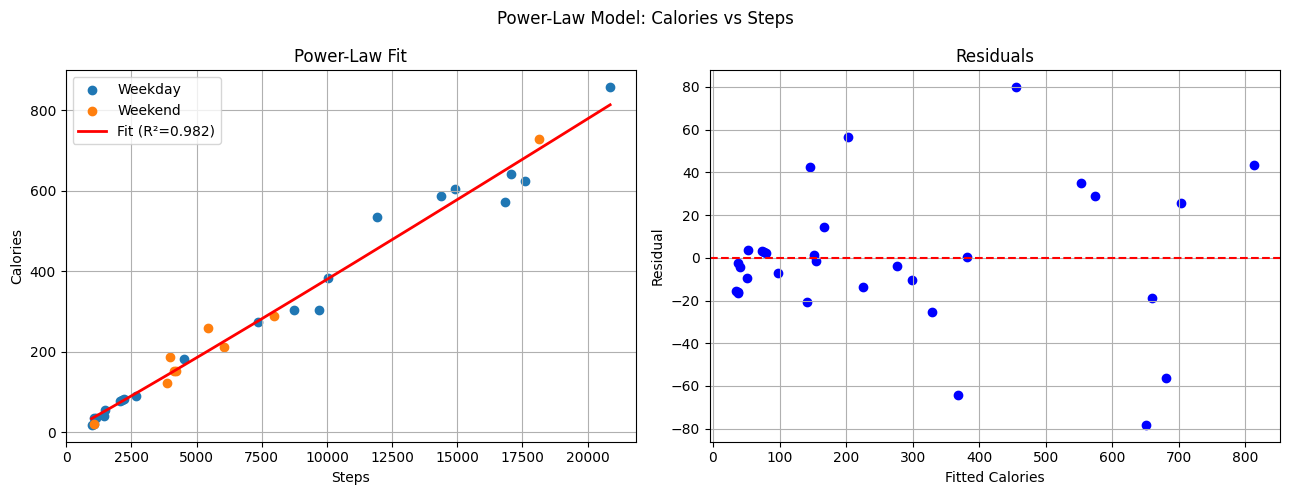

In [8]:

# Fit power-law model
def power_law(s, a, b):
    return a * (s ** b)

popt, pcov = curve_fit(power_law, df['Steps'], df['Calories'],
                       p0=[0.01, 1.1], maxfev=10000)

a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))

# R² calculation
pred = power_law(df['Steps'], a_fit, b_fit)

ss_res = np.sum((df['Calories'] - pred) ** 2)
ss_tot = np.sum((df['Calories'] - df['Calories'].mean()) ** 2)

r_squared = 1 - ss_res / ss_tot


# Print results
print("Power-law model fit:  Calories = a · Steps^b")
print(f"  a = {a_fit:.6f}  (±{perr[0]:.6f})")
print(f"  b = {b_fit:.6f}  (±{perr[1]:.6f})")
print(f"  R² = {r_squared:.4f}")

print(f"\nInterpretation: b = {b_fit:.3f}")
if b_fit > 1:
    print("  Increasing returns (more steps = much more calories)")
else:
    print("  Diminishing returns (extra steps give less gain)")


# Visualisation
plt.figure(figsize=(13, 5))

# 1. Scatter + fitted curve
plt.subplot(1, 2, 1)

plt.scatter(df[df['Weekdays']=='weekday']['Steps'],
            df[df['Weekdays']=='weekday']['Calories'],
            color='#1f77b4', label='Weekday')

plt.scatter(df[df['Weekdays']=='weekend']['Steps'],
            df[df['Weekdays']=='weekend']['Calories'],
            color='#ff7f0e', label='Weekend')

# Fitted curve
s_range = np.linspace(df['Steps'].min(), df['Steps'].max(), 300)
c_range = power_law(s_range, a_fit, b_fit)

plt.plot(s_range, c_range, 'r-', linewidth=2,
         label=f'Fit (R²={r_squared:.3f})')

plt.title('Power-Law Fit')
plt.xlabel('Steps')
plt.ylabel('Calories')
plt.legend()
plt.grid(True)


# 2. Residual plot
plt.subplot(1, 2, 2)

residuals = df['Calories'] - pred

plt.scatter(pred, residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')

plt.title('Residuals')
plt.xlabel('Fitted Calories')
plt.ylabel('Residual')
plt.grid(True)

# Final layout
plt.suptitle('Power-Law Model: Calories vs Steps')
plt.tight_layout()
plt.savefig('part3_model_fit.png', dpi=150)
plt.show()


## Optimisation

### Method: SLSQP with Multiple Random Restarts

The weekly calorie total is:

$$\text{Maximise} \quad \sum_{i=1}^{7} a \cdot s_i^{\,b}$$



In [5]:
# Constraint and bound values from personal data
WEEKDAY_MIN  =   971    # minimum steps ever recorded on a weekday
WEEKDAY_MAX  = 20866    # maximum steps ever recorded on a weekday
WEEKEND_MIN  =  1059    # minimum steps ever recorded on a weekend
WEEKEND_MAX  = 18132    # maximum steps ever recorded on a weekend
WEEKLY_MIN   = 10000    # minimum meaningful week
WEEKLY_MAX   = 90000    # realistic sustainable weekly ceiling

# Decision variables: [Mon, Tue, Wed, Thu, Fri, Sat, Sun]
# x[0]–x[4] = weekdays,  x[5]–x[6] = weekend
bounds = [
    (WEEKDAY_MIN, WEEKDAY_MAX),  # Monday
    (WEEKDAY_MIN, WEEKDAY_MAX),  # Tuesday
    (WEEKDAY_MIN, WEEKDAY_MAX),  # Wednesday
    (WEEKDAY_MIN, WEEKDAY_MAX),  # Thursday
    (WEEKDAY_MIN, WEEKDAY_MAX),  # Friday
    (WEEKEND_MIN, WEEKEND_MAX),  # Saturday
    (WEEKEND_MIN, WEEKEND_MAX),  # Sunday
]

# Constraints: weekly total must be between WEEKLY_MIN and WEEKLY_MAX
constraints = [
    {'type': 'ineq', 'fun': lambda x: WEEKLY_MAX - np.sum(x)},  # total <= 90,000
    {'type': 'ineq', 'fun': lambda x: np.sum(x) - WEEKLY_MIN},  # total >= 10,000
]

# Objective function
def total_weekly_calories(x):
    """Total calories burned in a week given daily step counts x."""
    return np.sum(power_law(np.array(x), a_fit, b_fit))

def negative_calories(x):
    """We minimise the negative (= maximise calories)."""
    return -total_weekly_calories(x)

# Run SLSQP with 30 random restarts
np.random.seed(42)
N_RESTARTS = 30
successful_results = []

print(f"Running SLSQP with {N_RESTARTS} random starting points...")

for i in range(N_RESTARTS):
    # Random starting point within bounds
    x_start = np.array([
        np.random.uniform(WEEKDAY_MIN, WEEKDAY_MAX),
        np.random.uniform(WEEKDAY_MIN, WEEKDAY_MAX),
        np.random.uniform(WEEKDAY_MIN, WEEKDAY_MAX),
        np.random.uniform(WEEKDAY_MIN, WEEKDAY_MAX),
        np.random.uniform(WEEKDAY_MIN, WEEKDAY_MAX),
        np.random.uniform(WEEKEND_MIN, WEEKEND_MAX),
        np.random.uniform(WEEKEND_MIN, WEEKEND_MAX),
    ])

    result = minimize(
        negative_calories,
        x_start,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000}
    )

    if result.success:
        successful_results.append((total_weekly_calories(result.x), result.x.copy()))

print(f"Successful runs: {len(successful_results)} / {N_RESTARTS}")

# Extract the best solution
best_calories, best_x = max(successful_results, key=lambda r: r[0])

# Print results
days = ['Monday    (weekday)', 'Tuesday   (weekday)', 'Wednesday (weekday)',
        'Thursday  (weekday)', 'Friday    (weekday)',
        'Saturday  (weekend)', 'Sunday    (weekend)']

print()
print("  OPTIMAL WEEKLY STEP PLAN")
print()
for day, steps in zip(days, best_x):
    cals = power_law(steps, a_fit, b_fit)
    print(f"  {day}  {steps:>7,.0f} steps  -  {cals:>6.1f} kcal")
print()
print(f"  {'WEEKLY TOTAL':<30}  {np.sum(best_x):>7,.0f} steps  -  {best_calories:>6.1f} kcal")
print()
print(f"  Weekly cap used: {np.sum(best_x)/WEEKLY_MAX*100:.1f}% of {WEEKLY_MAX:,} steps")

Running SLSQP with 30 random starting points...
Successful runs: 26 / 30

  OPTIMAL WEEKLY STEP PLAN

  Monday    (weekday)   20,866 steps  -   813.3 kcal
  Tuesday   (weekday)   20,866 steps  -   813.3 kcal
  Wednesday (weekday)   20,866 steps  -   813.3 kcal
  Thursday  (weekday)      971 steps  -    33.9 kcal
  Friday    (weekday)   20,866 steps  -   813.3 kcal
  Saturday  (weekend)    4,506 steps  -   166.1 kcal
  Sunday    (weekend)    1,059 steps  -    37.0 kcal

  WEEKLY TOTAL                     90,000 steps  -  3490.4 kcal

  Weekly cap used: 100.0% of 90,000 steps


## Sensitivity Analysis

Sensitivity analysis asks: how much does the optimal calorie burn change if the
weekly step cap is relaxed or tightened?


In [6]:
# 1. Sensitivity: vary weekly cap

cap_range = np.arange(40000, 125000, 5000)
opt_cals_by_cap = []

for cap in cap_range:

    # Constraints
    constraints = [
        {'type': 'ineq', 'fun': lambda x, c=cap: c - np.sum(x)},
        {'type': 'ineq', 'fun': lambda x: np.sum(x) - WEEKLY_MIN}
    ]

    best_cal = -np.inf

    # Try multiple starting points
    for _ in range(10):

        # Generate starting guess
        x0 = []
        for i in range(7):
            if i < 5:  # weekdays
                low, high = WEEKDAY_MIN, min(WEEKDAY_MAX, cap / 7)
            else:      # weekends
                low, high = WEEKEND_MIN, min(WEEKEND_MAX, cap / 7)

            x0.append(np.random.uniform(low, high))

        x0 = np.array(x0)

        # Optimisation
        result = minimize(negative_calories, x0,
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 2000})

        if result.success:
            best_cal = max(best_cal, total_weekly_calories(result.x))

    opt_cals_by_cap.append(best_cal)


# 2. Actual vs Optimal comparison
actual_mean_cals = df['Calories'].mean() * 7
actual_steps = df['Steps'].mean() * 7
actual_cals  = df['Calories'].mean() * 7

print("Comparison: Actual vs Optimal")
print(f"  Actual  : {actual_steps:,.0f} steps/week - {actual_cals:.1f} kcal")
print(f"  Optimal : {np.sum(best_x):,.0f} steps/week - {best_calories:.1f} kcal")

improvement = best_calories - actual_cals
percent = (improvement / actual_cals) * 100

print(f"  Gain    : +{improvement:.1f} kcal/week ({percent:.1f}%)")

Comparison: Actual vs Optimal
  Actual  : 50,811 steps/week - 1925.3 kcal
  Optimal : 90,000 steps/week - 3490.4 kcal
  Gain    : +1565.0 kcal/week (81.3%)



## Results Visualisation

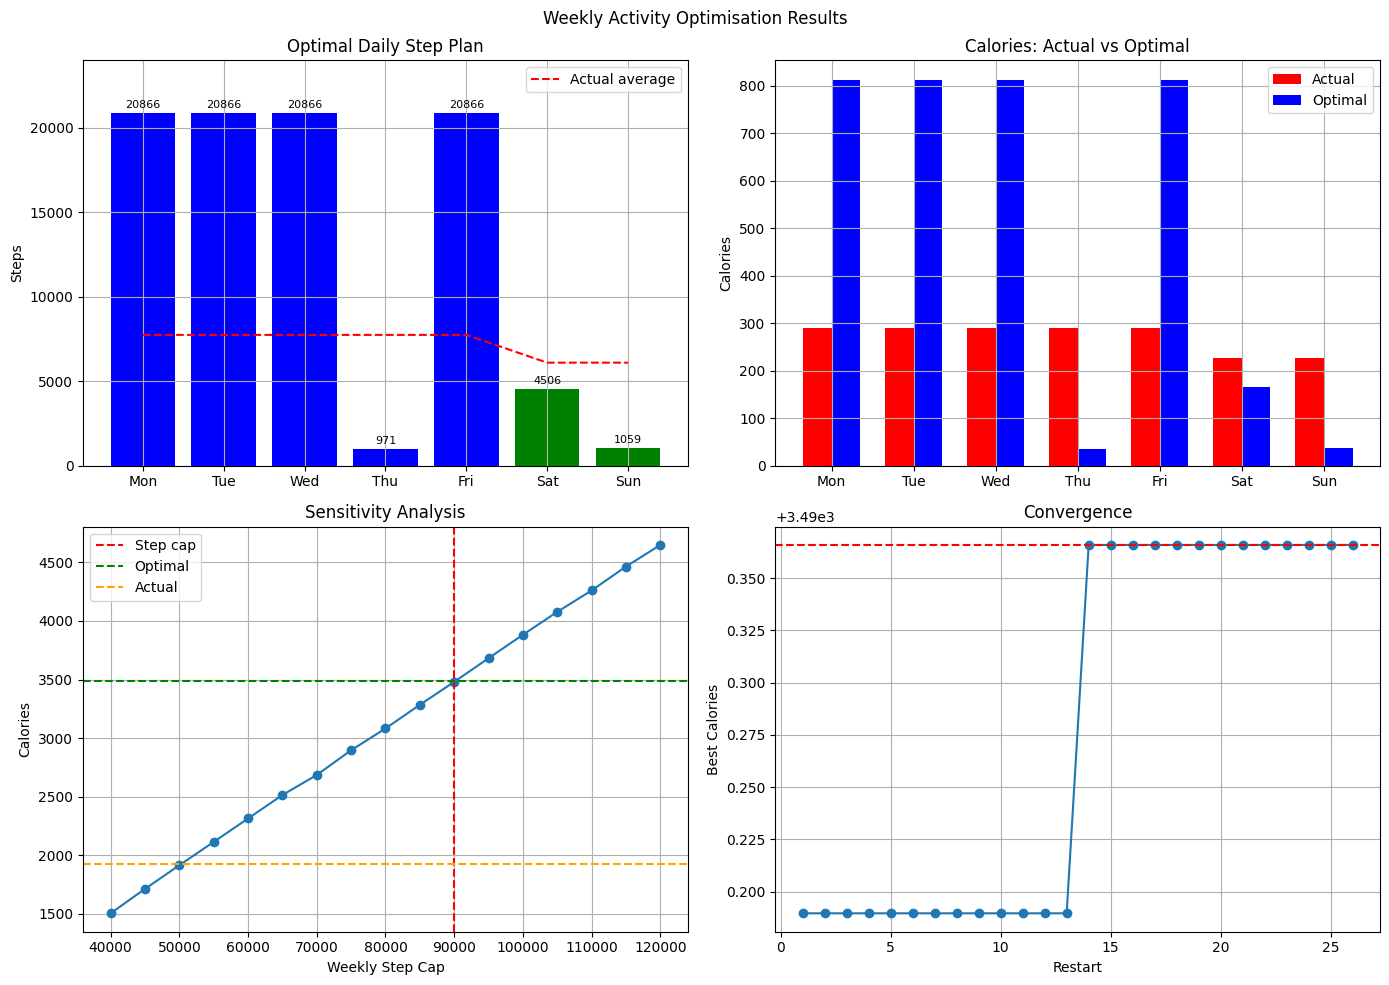

In [7]:
plt.figure(figsize=(14, 10))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_colors = ['blue']*5 + ['green']*2


# 1. Optimal step plan
plt.subplot(2, 2, 1)

bars = plt.bar(day_labels, best_x, color=day_colors)

# Reference line (actual averages)
actual_wkday = df[df['Weekdays']=='weekday']['Steps'].mean()
actual_wkend = df[df['Weekdays']=='weekend']['Steps'].mean()
ref_means = [actual_wkday]*5 + [actual_wkend]*2

plt.plot(day_labels, ref_means, 'r--', label='Actual average')

# Add values on bars
for i in range(len(best_x)):
    plt.text(i, best_x[i] + 300, f'{best_x[i]:.0f}', ha='center', fontsize=8)

plt.title('Optimal Daily Step Plan')
plt.ylabel('Steps')
plt.ylim(0, 24000)
plt.legend()
plt.grid(True)


# 2. Calories comparison
plt.subplot(2, 2, 2)

opt_cals = [power_law(s, a_fit, b_fit) for s in best_x]
act_cals = [power_law(m, a_fit, b_fit) for m in ref_means]

x = np.arange(7)
w = 0.35

plt.bar(x - w/2, act_cals, w, label='Actual', color='red')
plt.bar(x + w/2, opt_cals, w, label='Optimal', color='blue')

plt.xticks(x, day_labels)
plt.title('Calories: Actual vs Optimal')
plt.ylabel('Calories')
plt.legend()
plt.grid(True)


# 3. Sensitivity plot
plt.subplot(2, 2, 3)

plt.plot(cap_range, opt_cals_by_cap, 'o-')

plt.axvline(WEEKLY_MAX, color='red', linestyle='--', label='Step cap')
plt.axhline(best_calories, color='green', linestyle='--', label='Optimal')
plt.axhline(actual_mean_cals, color='orange', linestyle='--', label='Actual')

plt.title('Sensitivity Analysis')
plt.xlabel('Weekly Step Cap')
plt.ylabel('Calories')
plt.legend()
plt.grid(True)


# 4. Convergence plot
plt.subplot(2, 2, 4)

running_best = []
for i in range(len(successful_results)):
    best_val = max(r[0] for r in successful_results[:i+1])
    running_best.append(best_val)

plt.plot(range(1, len(running_best)+1), running_best, 'o-')
plt.axhline(best_calories, color='red', linestyle='--')

plt.title('Convergence')
plt.xlabel('Restart')
plt.ylabel('Best Calories')
plt.grid(True)


# Final layout
plt.suptitle('Weekly Activity Optimisation Results')
plt.tight_layout()
plt.savefig('part3_results.png', dpi=150)
plt.show()

print()